# 09. Мартингалы и моменты остановки

**Статус:** завершено

Мартингал — математическая модель честной игры: при известной текущей информации условное среднее будущего равно текущему значению. В этом ноутбуке мы изучим фильтрацию, остановку, барьеры, теорему об остановке и ловушки «стратегий гарантированного выигрыша».

## Теория

Пусть $\mathcal F_n$ — информация, доступная к моменту $n$. Процесс $M_n$ называется мартингалом, если он адаптирован к $\mathcal F_n$, интегрируем и

$$\mathbb E[M_{n+1}\mid \mathcal F_n]=M_n.$$

Симметричное случайное блуждание $S_n=\sum_{k=1}^n \xi_k$, где $\xi_k=\pm1$ с вероятностями 0.5, является мартингалом.

Момент остановки $\tau$ — случайное время, для которого событие $\{\tau\le n\}$ известно по информации к моменту $n$. Например, первое достижение барьера — момент остановки.

Теорема об остановке говорит, что при подходящих условиях

$$\mathbb E[M_\tau]=\mathbb E[M_0].$$

Но условия важны: без ограниченности времени, интегрируемости или контроля хвостов можно получить неверные выводы.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.martingales_stopping_times import (
    calculate_theoretical_expected_stopping_time_symmetric_walk,
    calculate_theoretical_upper_barrier_probability_symmetric_walk,
    plot_martingale_mean_over_time,
    plot_random_walk_and_stopped_paths,
    plot_stopping_time_distribution,
    simulate_doubling_strategy_until_win_or_limit,
    simulate_symmetric_random_walk_paths,
    stop_random_walk_at_barriers,
)

## 1. Симметричное случайное блуждание как мартингал

,Показатель,Значение
0,E[S_tau] симуляция,-0.0134
1,P(hit +8 first) симуляция,0.3835
2,P(hit +8 first) теория,0.3846
3,E[tau] симуляция,39.7481
4,E[tau] теория,40.0000


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  func(*args, **kwargs)


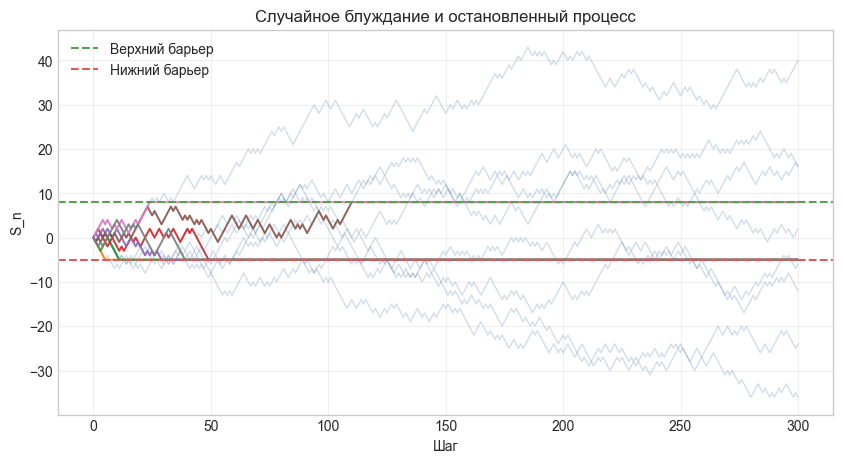

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8743 (\N{LOGICAL AND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


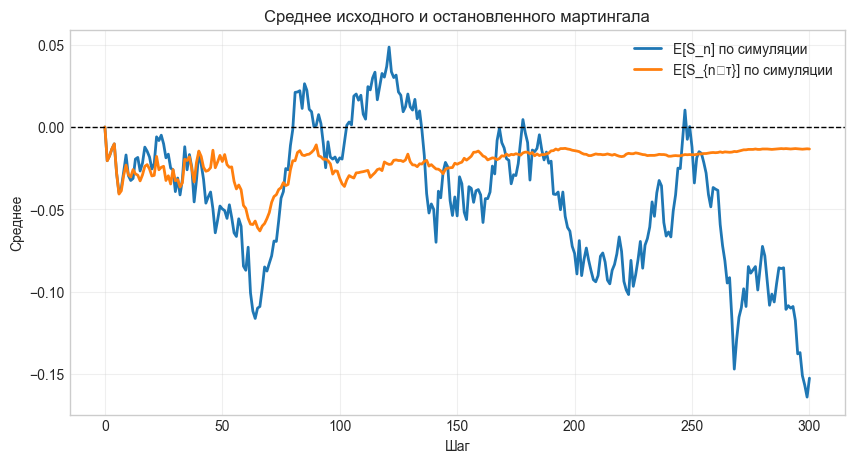

In [2]:
step_grid, random_walk_paths = simulate_symmetric_random_walk_paths(8000, 300, random_seed=123)
stopped_paths, stopping_times, stopped_values = stop_random_walk_at_barriers(random_walk_paths, upper_barrier=8, lower_barrier=-5)
plot_random_walk_and_stopped_paths(step_grid, random_walk_paths, stopped_paths, 8, -5, "Случайное блуждание и остановленный процесс");
plot_martingale_mean_over_time(step_grid, random_walk_paths, stopped_paths, "Среднее исходного и остановленного мартингала");

pd.DataFrame({
    "Показатель": ["E[S_tau] симуляция", "P(hit +8 first) симуляция", "P(hit +8 first) теория", "E[tau] симуляция", "E[tau] теория"],
    "Значение": [stopped_values.mean(), np.mean(stopped_values == 8), calculate_theoretical_upper_barrier_probability_symmetric_walk(8,-5), stopping_times.mean(), calculate_theoretical_expected_stopping_time_symmetric_walk(8,-5)]
})

Остановленное среднее остаётся около нуля: `E[S_tau] = -0.0134`. Это визуально и численно подтверждает идею теоремы об остановке для ограниченного барьерного времени.

Вероятность попасть в верхний барьер `+8` раньше нижнего `-5` равна `0.3835`, теория даёт `0.3846`. Среднее время остановки `39.7481` близко к теоретическим `40`. Из равенства $E[S_\tau]=0$ можно вывести вероятность выигрыша: $8p-5(1-p)=0$, отсюда $p=5/13$.

## 2. Распределение времени остановки

,Квантиль,tau
0,25%,15.0
1,50%,29.0
2,75%,53.0


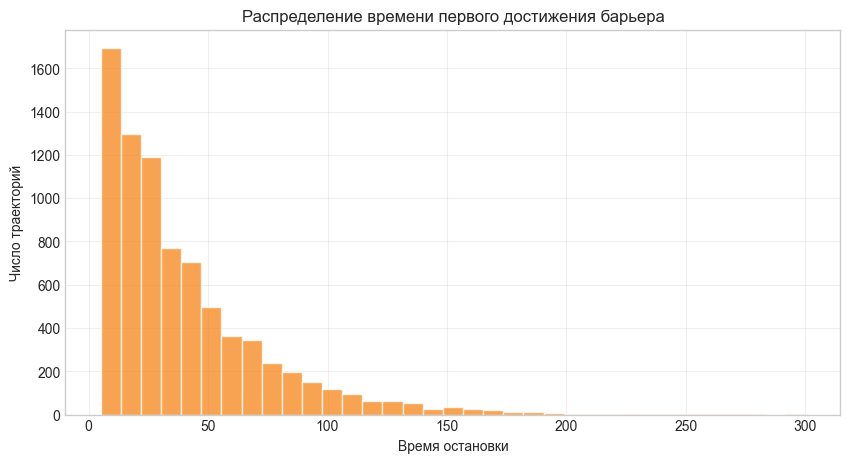

In [3]:
plot_stopping_time_distribution(stopping_times, "Распределение времени первого достижения барьера");
pd.DataFrame({"Квантиль": ["25%", "50%", "75%"], "tau": np.quantile(stopping_times, [.25,.5,.75])})

Время остановки имеет правый хвост: квантили `15`, `29`, `53`. Многие траектории быстро достигают одного из барьеров, но часть долго блуждает между ними. Это важная практическая деталь: даже если ожидаемое время конечно, длительные ожидания не редкость.

## 3. Некорректная интуиция: стратегия удвоения ставки

In [4]:
profits, maximum_bets = simulate_doubling_strategy_until_win_or_limit(
    number_of_trials=20000,
    maximum_number_of_losses=8,
    random_seed=321,
)

pd.DataFrame({
    "Показатель": ["Средний profit", "Доля положительных исходов", "Худший исход", "Максимальная ставка"],
    "Значение": [profits.mean(), np.mean(profits > 0), profits.min(), maximum_bets.max()]
})

,Показатель,Значение
0,Средний profit,0.3088
1,Доля положительных исходов,0.9987
2,Худший исход,-511.0000
3,Максимальная ставка,256.0000


Стратегия удвоения выглядит соблазнительно: почти всегда она даёт маленький выигрыш. В симуляции доля положительных исходов `0.9986`. Но редкий проигрыш огромен: худший исход `-511`, максимальная ставка `256`, а средний profit всего `0.3088` в конечной симуляции и сильно зависит от лимита.

Математический урок: нельзя применять теорему об остановке без проверки условий. Идея «я когда-нибудь отыграюсь» требует бесконечного капитала и отсутствия лимитов, а это не честная допустимая стратегия в реальной модели.

## Выводы

1. Мартингал формализует честную игру относительно текущей информации.
2. Первое достижение барьера является моментом остановки.
3. Для ограниченных барьеров теорема об остановке хорошо работает и даёт вероятности выигрыша.
4. Остановленное случайное блуждание сохраняет среднее около начального значения.
5. Условия теоремы об остановке принципиальны: стратегии с редкими катастрофическими проигрышами не создают настоящий арбитраж.